Analyzing...
1. shape of df
2. feature df types
3. classification balance
4. missing values

In [34]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OrdinalEncoder


In [35]:
df = pd.read_csv("../data/raw/term-deposit-marketing-2020.csv")

In [36]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,no


! need to make categorical variables into numerical df types so that df is consistent 

In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        40000 non-null  int64
 1   job        40000 non-null  str  
 2   marital    40000 non-null  str  
 3   education  40000 non-null  str  
 4   default    40000 non-null  str  
 5   balance    40000 non-null  int64
 6   housing    40000 non-null  str  
 7   loan       40000 non-null  str  
 8   contact    40000 non-null  str  
 9   day        40000 non-null  int64
 10  month      40000 non-null  str  
 11  duration   40000 non-null  int64
 12  campaign   40000 non-null  int64
 13  y          40000 non-null  str  
dtypes: int64(5), str(9)
memory usage: 4.3 MB


In [38]:
#finding class imbalance
counts = df.y.value_counts()
print("Positive Classification :",
      round(counts.iloc[1]/counts.iloc[0] * 100), "%")



Positive Classification : 8 %


In [39]:
df.describe()

,age,balance,day,duration,campaign
count,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,40.544600,1274.277550,16.017225,254.824300,2.882175
std,9.641776,2903.769716,8.278127,259.366498,3.239051
min,19.000000,-8019.000000,1.000000,0.000000,1.000000
25%,33.000000,54.000000,8.000000,100.000000,1.000000
50%,39.000000,407.000000,17.000000,175.000000,2.000000
75%,48.000000,1319.000000,21.000000,313.000000,3.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000


In [40]:
#finding columns with unknown values
for column in df:
    print(column)
    print(df[column].unique())

age
[58 44 33 47 35 28 42 43 41 29 53 57 51 45 60 56 32 25 40 39 52 46 36 49
 59 37 50 54 55 48 24 38 31 30 27 34 23 26 61 22 21 20 66 62 83 75 67 70
 65 68 64 69 72 71 19 76 85 63 90 82 73 74 78 80 94 79 77 86 95 81]
job
<StringArray>
[   'management',    'technician',  'entrepreneur',   'blue-collar',
       'unknown',       'retired',         'admin',      'services',
 'self-employed',    'unemployed',     'housemaid',       'student']
Length: 12, dtype: str
marital
<StringArray>
['married', 'single', 'divorced']
Length: 3, dtype: str
education
<StringArray>
['tertiary', 'secondary', 'unknown', 'primary']
Length: 4, dtype: str
default
<StringArray>
['no', 'yes']
Length: 2, dtype: str
balance
[  2143     29      2 ...   7222   3402 102127]
housing
<StringArray>
['yes', 'no']
Length: 2, dtype: str
loan
<StringArray>
['no', 'yes']
Length: 2, dtype: str
contact
<StringArray>
['unknown', 'cellular', 'telephone']
Length: 3, dtype: str
day
[ 5  6  7  8  9 12 13 14 15 16 19 20 21 23 26 27 2

In [41]:
#extracting columns with unknown values
print("Count unknown job",(df.job == "unknown").sum())
print("Count unknown education",(df.education == "unknown").sum())
print("Count unknown contact method",(df.contact == "unknown").sum())


Count unknown job 235
Count unknown education 1531
Count unknown contact method 12765


* Contact method may not correlate to subscription rate, so the missing feature may be okay. We will have to investigate further
* For job and education, these make up less than 5% of the df. 
* Before we remove any rows or features, I want to ensure that this df are missing by random. Let's check the distribution of rows with unknown education, job, and contact method.

# Encoding categorical and binary variables

In [42]:
#map binary categories
bool_df = df.copy() #preserve original df

bool_df['y'] = df['y'].map({'no': False, 'yes': True})  
bool_df['default'] = df['default'].map({'no': False, 'yes': True}) 
bool_df['housing'] = df['housing'].map({'no': False, 'yes': True}) 
bool_df['loan'] = df['loan'].map({'no': False, 'yes': True}) 

bool_df.head(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,management,married,tertiary,False,2143,True,False,unknown,5,may,261,1,False
1,44,technician,single,secondary,False,29,True,False,unknown,5,may,151,1,False
2,33,entrepreneur,married,secondary,False,2,True,True,unknown,5,may,76,1,False
3,47,blue-collar,married,unknown,False,1506,True,False,unknown,5,may,92,1,False
4,33,unknown,single,unknown,False,1,False,False,unknown,5,may,198,1,False


# Dummy Encoding

In [43]:
#1st method of encoding categorical variables 
dummy_df = pd.get_dummies(bool_df, 
                              columns=['job','marital','education','contact','month'], 
                              drop_first=True)

dummy_df.head(5)

,age,default,balance,housing,loan,day,duration,campaign,y,job_blue-collar,...,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct
0,58,False,2143,True,False,5,261,1,False,False,...,False,False,False,False,False,False,False,True,False,False
1,44,False,29,True,False,5,151,1,False,False,...,False,False,False,False,False,False,False,True,False,False
2,33,False,2,True,True,5,76,1,False,False,...,False,False,False,False,False,False,False,True,False,False
3,47,False,1506,True,False,5,92,1,False,True,...,False,False,False,False,False,False,False,True,False,False
4,33,False,1,False,False,5,198,1,False,False,...,False,False,False,False,False,False,False,True,False,False


In [44]:
dummy_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 37 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   age                  40000 non-null  int64
 1   default              40000 non-null  bool 
 2   balance              40000 non-null  int64
 3   housing              40000 non-null  bool 
 4   loan                 40000 non-null  bool 
 5   day                  40000 non-null  int64
 6   duration             40000 non-null  int64
 7   campaign             40000 non-null  int64
 8   y                    40000 non-null  bool 
 9   job_blue-collar      40000 non-null  bool 
 10  job_entrepreneur     40000 non-null  bool 
 11  job_housemaid        40000 non-null  bool 
 12  job_management       40000 non-null  bool 
 13  job_retired          40000 non-null  bool 
 14  job_self-employed    40000 non-null  bool 
 15  job_services         40000 non-null  bool 
 16  job_student          40000 non-nu

# Ordinal Encoding

In [45]:
#taking out rows with missing values for encoded df
encoded_df = df.copy()
encoded_df = df[df['job'] != 'unknown'] 
encoded_df = df[df['education'] != 'unknown']
encoded_df_with_contact = encoded_df.copy()
encoded_df = df[df['contact'] != 'unknown']

In [46]:
#2nd method of encoding categorical variables 
category_columns = df.select_dtypes(include="object").columns.drop('month')

enc = OrdinalEncoder()
encoded_df[category_columns] = enc.fit_transform(encoded_df[category_columns])
encoded_df_with_contact[category_columns] = enc.fit_transform(encoded_df_with_contact[category_columns])



/var/folders/2t/jlwt4t955m5g3f49k1zzh5100000gn/T/ipykernel_72289/1251895507.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  category_columns = df.select_dtypes(include="object").columns.drop('month')


In [47]:

month_map = {
    'jan': 1,
    'feb': 2,
    'mar': 3,
    'apr': 4,
    'may': 5,
    'jun': 6,
    'jul': 7,
    'aug': 8,
    'sep': 9,
    'oct': 10,
    'nov': 11,
    'dec': 12
}
#mapping months to number rather than str
df_temp = df.copy()
df_temp['month'] = df['month'].str.lower().map(month_map).astype(int)

#cyclic encoding to perserve nature of time
encoded_df['month_sin'] = np.sin(2 * np.pi * df_temp['month'] / 12)
encoded_df['month_cos'] = np.cos(2 * np.pi * df_temp['month'] / 12)
encoded_df_with_contact['month_sin'] = np.sin(2 * np.pi * df_temp['month'] / 12)
encoded_df_with_contact['month_cos'] = np.cos(2 * np.pi * df_temp['month'] / 12)

#drop column
encoded_df.drop(columns="month", inplace=True)
encoded_df_with_contact.drop(columns="month", inplace=True)

In [48]:
encoded_df.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,duration,campaign,y,month_sin,month_cos
12657,27,4.0,2.0,1.0,0.0,35,0.0,0.0,0.0,4,255,1,0.0,-0.5,-0.866025
12658,54,1.0,1.0,0.0,0.0,466,0.0,0.0,0.0,4,297,1,0.0,-0.5,-0.866025
12659,43,1.0,1.0,1.0,0.0,105,0.0,1.0,0.0,4,668,2,0.0,-0.5,-0.866025
12660,31,9.0,2.0,1.0,0.0,19,0.0,0.0,1.0,4,65,2,0.0,-0.5,-0.866025
12661,27,9.0,2.0,1.0,0.0,126,1.0,1.0,0.0,4,436,4,0.0,-0.5,-0.866025


In [49]:
encoded_df_with_contact.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,duration,campaign,y,month_sin,month_cos
0,58,4.0,1.0,2.0,0.0,2143,1.0,0.0,2.0,5,261,1,0.0,0.5,-0.866025
1,44,9.0,2.0,1.0,0.0,29,1.0,0.0,2.0,5,151,1,0.0,0.5,-0.866025
2,33,2.0,1.0,1.0,0.0,2,1.0,1.0,2.0,5,76,1,0.0,0.5,-0.866025
5,35,4.0,1.0,2.0,0.0,231,1.0,0.0,2.0,5,139,1,0.0,0.5,-0.866025
6,28,4.0,2.0,2.0,0.0,447,1.0,1.0,2.0,5,217,1,0.0,0.5,-0.866025


In [50]:
#export to csv
encoded_df_with_contact.to_csv('../data/processed/encoded_df_with_contact.csv', index=False)
encoded_df.to_csv('../data/processed/encoded_df_no_missing.csv', index=False)

# Testing Correlation

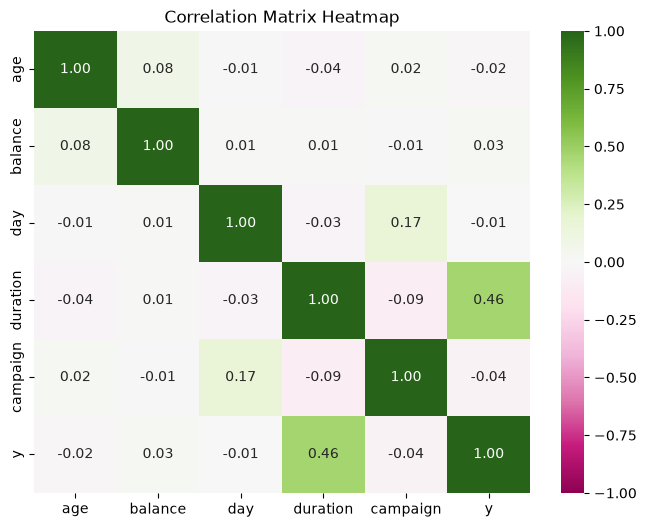

In [51]:
#finding correlation of continuous values using correlation matrix
corr_matrix = dummy_df[['age','balance','day','duration','campaign','y']].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, 
    annot=True,          # Show values inside cells
    cmap='PiYG',
    vmin=-1, vmax=1,     # Bound color scale between -1 and 1
    fmt=".2f"            # Round to 2 decimal places
)
plt.title('Correlation Matrix Heatmap')
plt.show()


Of the continuous values, 'duration' and 'campaign' are the most correlated to 'y'.

/var/folders/2t/jlwt4t955m5g3f49k1zzh5100000gn/T/ipykernel_72289/1241043987.py:2: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': '#e3307d'}` instead.

  plot = sns.barplot(bool_df, x='job', y='y', color="#839791", errcolor="#e3307d")


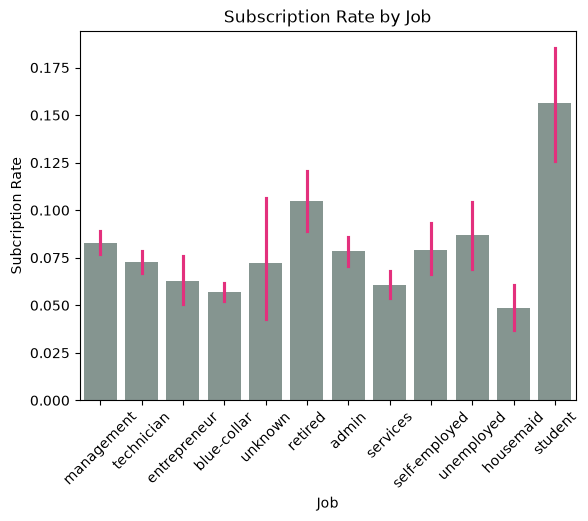

In [52]:
#finding correlation of job to subscription rate using bar chart
plot = sns.barplot(bool_df, x='job', y='y', color="#839791", errcolor="#e3307d")

plt.xlabel('Job')
plt.xticks(rotation=45)
plt.ylabel('Subcription Rate')
plt.title('Subscription Rate by Job')
plt.show()

* Students have the highest term deposit subscription rate. 
* 'Retired', 'management', 'admin' and 'unemployed' look to be likely to subscribe to a term deposit, but more analysis may need to be done to prove statistical significance. 
* Those who declined to submit their job do not have an exceptionally low or high subscription rate. We can safely remove these missing values. 

/var/folders/2t/jlwt4t955m5g3f49k1zzh5100000gn/T/ipykernel_72289/583011077.py:3: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': '#e3307d'}` instead.

  plot = sns.barplot(bool_df, x='marital', y='y', color="#839791", errcolor="#e3307d")


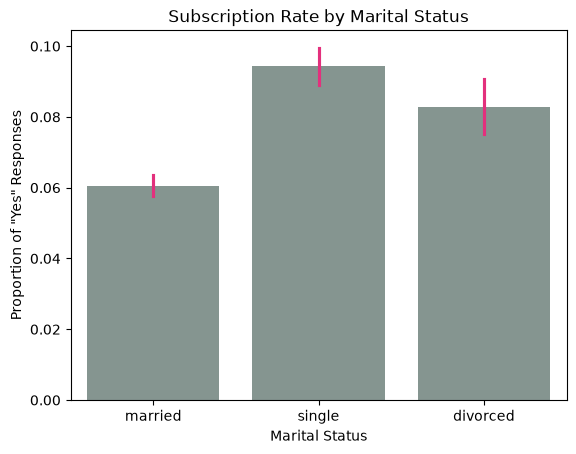

In [53]:
#finding correlation of marital status to subscription rate using bar chart

plot = sns.barplot(bool_df, x='marital', y='y', color="#839791", errcolor="#e3307d")

plt.xlabel('Marital Status')
plt.ylabel('Proportion of "Yes" Responses')
plt.title('Subscription Rate by Marital Status')
plt.show()

Single customers may have a statistically significant, higher subscription rate than married or divorced customers

/var/folders/2t/jlwt4t955m5g3f49k1zzh5100000gn/T/ipykernel_72289/3938669552.py:3: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': '#e3307d'}` instead.

  plot = sns.barplot(bool_df, x='education', y='y', color="#839791", errcolor="#e3307d")


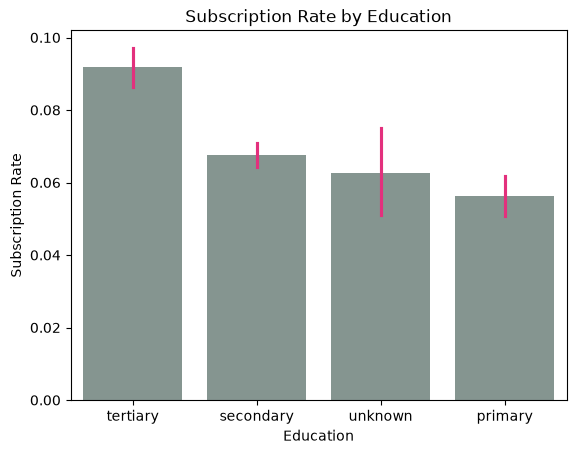

In [54]:
#finding correlation of education to subscription rate using bar chart

plot = sns.barplot(bool_df, x='education', y='y', color="#839791", errcolor="#e3307d")

plt.xlabel('Education')
plt.ylabel('Subscription Rate')
plt.title('Subscription Rate by Education')
plt.show()

* Those whose education status was marked as tertiary have the highest term deposit subscription rate.
* Those who declined to submit their education do not have an exceptionally low or high subscription rate. We can safely remove these missing values. 

/var/folders/2t/jlwt4t955m5g3f49k1zzh5100000gn/T/ipykernel_72289/3040355858.py:3: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': '#e3307d'}` instead.

  plot = sns.barplot(bool_df, x='default', y='y', color="#839791", errcolor="#e3307d")


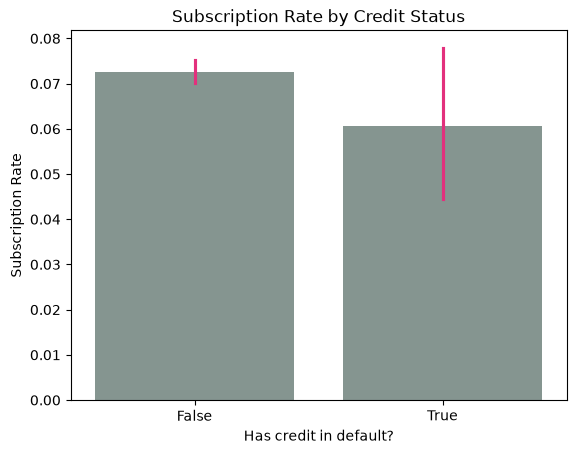

In [55]:
#finding correlation of credit status to subscription rate using bar chart

plot = sns.barplot(bool_df, x='default', y='y', color="#839791", errcolor="#e3307d")

plt.xlabel('Has credit in default?')
plt.ylabel('Subscription Rate')
plt.title('Subscription Rate by Credit Status')
plt.show()

The credit status does not seem to be highly correlated to subscription rate as the error bars greatly overlap.

/var/folders/2t/jlwt4t955m5g3f49k1zzh5100000gn/T/ipykernel_72289/186178194.py:3: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': '#e3307d'}` instead.

  plot = sns.barplot(bool_df, x='loan', y='y', color="#839791", errcolor='#e3307d')


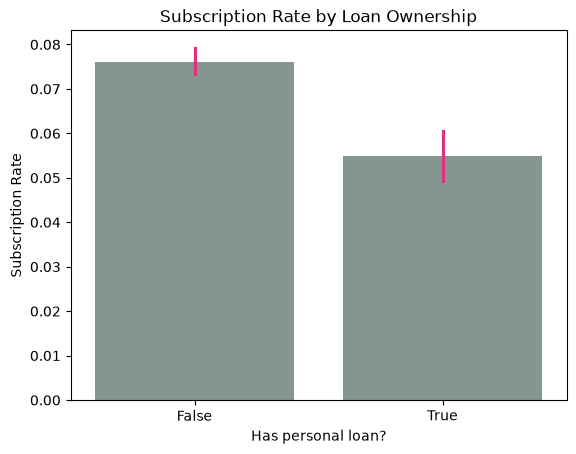

In [56]:
#finding correlation of loan ownership to subscription rate using bar chart

plot = sns.barplot(bool_df, x='loan', y='y', color="#839791", errcolor='#e3307d')

plt.xlabel('Has personal loan?')
plt.ylabel('Subscription Rate')
plt.title('Subscription Rate by Loan Ownership')
plt.show()

Customers without a personal loan may look to have a larger subscription rate than those without a personal loan, but more analysis will need to be done to ensure statistical significance as the scale shown here is very small.

/var/folders/2t/jlwt4t955m5g3f49k1zzh5100000gn/T/ipykernel_72289/2984760760.py:3: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': '#e3307d'}` instead.

  plot = sns.barplot(bool_df, x='contact', y='y', color="#839791", errcolor="#e3307d")


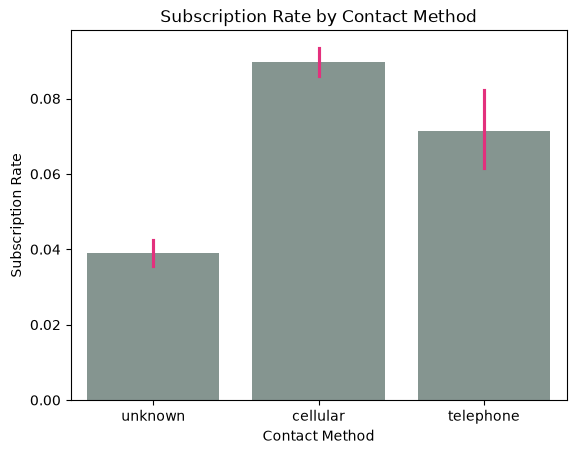

In [57]:
#finding correlation of listed contact method to subscription rate using bar chart

plot = sns.barplot(bool_df, x='contact', y='y', color="#839791", errcolor="#e3307d")

plt.xlabel('Contact Method')
plt.ylabel('Subscription Rate')
plt.title('Subscription Rate by Contact Method')
plt.show()

It looks like those with an unknown contact method have a much lower subscription rate. This may be due to customers asking to be taken off calling lists. 
I'm curious to see how the model would perform keeping the rows with the missing values vs. removing the feature entirely.

/var/folders/2t/jlwt4t955m5g3f49k1zzh5100000gn/T/ipykernel_72289/1322356633.py:3: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': '#e3307d'}` instead.

  plot = sns.barplot(bool_df, x='day', y='y', color="#839791", errcolor="#e3307d")


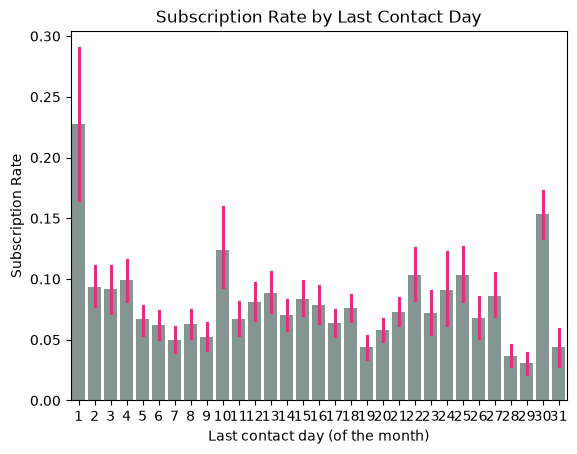

In [58]:
#finding correlation of last day contacted to subscription rate using bar chart

plot = sns.barplot(bool_df, x='day', y='y', color="#839791", errcolor="#e3307d")

plt.xlabel('Last contact day (of the month)')
plt.ylabel('Subscription Rate')
plt.title('Subscription Rate by Last Contact Day')
plt.show()

End Through the 1st of each month have the highest subscription rates.

/var/folders/2t/jlwt4t955m5g3f49k1zzh5100000gn/T/ipykernel_72289/3431765766.py:3: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': '#e3307d'}` instead.

  plot = sns.barplot(bool_df, x='month', y='y', color="#839791", errcolor="#e3307d")


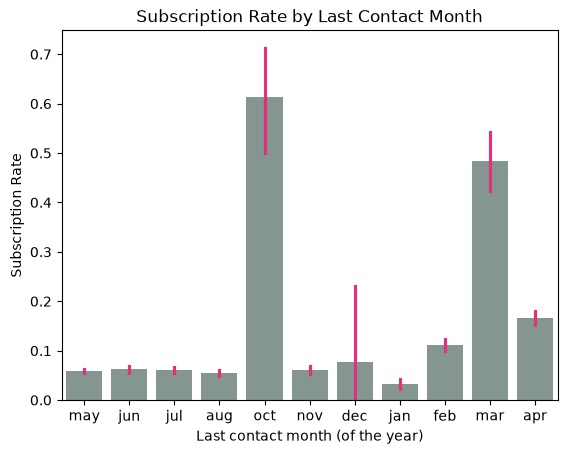

In [59]:
#finding correlation of month contacted to subscription rate using bar chart

plot = sns.barplot(bool_df, x='month', y='y', color="#839791", errcolor="#e3307d")

plt.xlabel('Last contact month (of the year)')
plt.ylabel('Subscription Rate')
plt.title('Subscription Rate by Last Contact Month')
plt.show()

Why do October and March particularly have high subscription rates? Does it have to do with financial quarters?


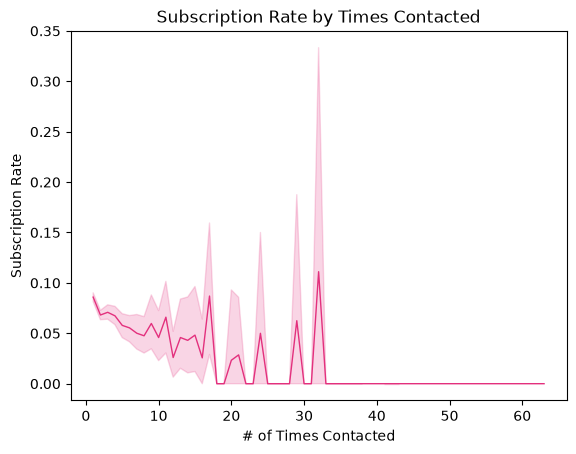

In [60]:
#finding correlation of job to subscription rate using bar chart

plot = sns.lineplot(bool_df, x='campaign', y='y', color="#e3307d", linewidth=1, )

plt.xlabel('# of Times Contacted')
plt.ylabel('Subscription Rate')
plt.title('Subscription Rate by Times Contacted')
plt.show()

Subscription rate falls as times contacted increases. Though there are some sharp blimps in this pattern, the error margin shows that this could be due to small sample size.

# Removing Missing Values

In [61]:
dummy_df.columns

Index(['age', 'default', 'balance', 'housing', 'loan', 'day', 'duration',
       'campaign', 'y', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_married', 'marital_single', 'education_secondary',
       'education_tertiary', 'education_unknown', 'contact_telephone',
       'contact_unknown', 'month_aug', 'month_dec', 'month_feb', 'month_jan',
       'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov',
       'month_oct'],
      dtype='str')

In [62]:
#taking out rows with missing values for dummy df
dummy_df_no_missing = dummy_df.copy()
dummy_df_no_missing = dummy_df[dummy_df['job_unknown'] != True] 
dummy_df_no_missing = dummy_df[dummy_df['education_unknown'] != True]
dummy_df_with_contact = dummy_df_no_missing.copy()
dummy_df_no_missing = dummy_df[dummy_df['contact_unknown'] != True]

#removing features
dummy_df_no_missing.drop(columns=['job_unknown','education_unknown','contact_unknown'], inplace=True)
dummy_df_with_contact.drop(columns=['job_unknown','education_unknown'], inplace=True)


In [63]:
dummy_df_no_missing.info()

<class 'pandas.DataFrame'>
Index: 27235 entries, 12657 to 39999
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   age                  27235 non-null  int64
 1   default              27235 non-null  bool 
 2   balance              27235 non-null  int64
 3   housing              27235 non-null  bool 
 4   loan                 27235 non-null  bool 
 5   day                  27235 non-null  int64
 6   duration             27235 non-null  int64
 7   campaign             27235 non-null  int64
 8   y                    27235 non-null  bool 
 9   job_blue-collar      27235 non-null  bool 
 10  job_entrepreneur     27235 non-null  bool 
 11  job_housemaid        27235 non-null  bool 
 12  job_management       27235 non-null  bool 
 13  job_retired          27235 non-null  bool 
 14  job_self-employed    27235 non-null  bool 
 15  job_services         27235 non-null  bool 
 16  job_student          27235 non-nul

In [64]:
dummy_df_with_contact.to_csv('../data/processed/dummy_df_with_contact.csv', index=False)
dummy_df_no_missing.to_csv('../data/processed/dummy_df_no_missing.csv', index=False)
dummy_df.to_csv('../data/interim/dummy_df.csv', index=False)